# 📊 Pre-Annotation Data Preparation

## Aspect-Based Sentiment Analysis (ABSA) — Lip Product Reviews (Female Daily)

**Pipeline ini mencakup:**

1. Setup & Import Library
2. Load & Inspeksi Data
3. Validasi Struktur Data
4. Standarisasi Format Kolom
5. Filtering Data Tidak Relevan
6. Cleaning `review_text`
7. Eksplorasi Data (EDA)
8. Ekspor Dataset untuk Label Studio


---

## 1. Setup & Import Library


In [1]:
!pip install pandas numpy matplotlib seaborn
!pip install nltk regex unicodedata2
!pip install Sastrawi  
!pip install langdetect  
!pip install wordcloud 
!pip install ftfy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.9/531.9 kB 13.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 22.3 MB/s eta 0:00:0000:01
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=c8213ca70d519347d599191fc59f565f19698755efbfb62bacfb509eeb1d9a86
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import unicodedata
import warnings
import json
from datetime import datetime
from collections import Counter

import ftfy

import nltk
from nltk.tokenize import word_tokenize

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from langdetect import detect, LangDetectException

warnings.filterwarnings('ignore')
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Konfigurasi tampilan
pd.set_option('display.max_colwidth', 150)
pd.set_option('display.max_columns', 20)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print("✅ Semua library berhasil diimport")
print(f"📅 Tanggal preprocessing: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Semua library berhasil diimport
📅 Tanggal preprocessing: 2026-03-18 12:40:49


---

## 2. Load & Inspeksi Data Awal


In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive berhasil di-mount!")

Mounted at /content/drive
✅ Google Drive berhasil di-mount!


In [4]:
DRIVE_DATA_DIR = '/content/drive/MyDrive/TA/data/'
FILE_PATH = DRIVE_DATA_DIR + '4200_test_raw_data4.csv'
df_raw = pd.read_csv(FILE_PATH, encoding='utf-8')

print(f"✅ Data berhasil dimuat")
print(f"📦 Jumlah baris   : {df_raw.shape[0]:,}")
print(f"📦 Jumlah kolom   : {df_raw.shape[1]}")
print(f"📋 Nama kolom     : {list(df_raw.columns)}")

✅ Data berhasil dimuat
📦 Jumlah baris   : 4,200
📦 Jumlah kolom   : 7
📋 Nama kolom     : ['product_url', 'product_brand', 'product_name', 'product_shade', 'product_price', 'review_date', 'review_text']


In [5]:
# Tampilkan 5 baris pertama
print("=" * 60)
print("PREVIEW DATA (5 baris pertama)")
print("=" * 60)
df_raw.head()

PREVIEW DATA (5 baris pertama)


,product_url,product_brand,product_name,product_shade,product_price,review_date,review_text
0,https://reviews.femaledaily.com/products/lips/lipstick/omg/oh-my-glam-mattelast-lip-cream-24-berry,OMG,Oh My Glam Mattelast Lip Cream,24 Berry,Rp.27.500,19 Feb 2026,"Omg tuh selain harganya yang affordable, ternyata kualitasnya oke juga. Menurutku dia teksturnya cukup ringan di bibir, buat nutupin bibir yg hita..."
1,https://reviews.femaledaily.com/products/lips/lipstick/omg/oh-my-glam-mattelast-lip-cream-24-berry,OMG,Oh My Glam Mattelast Lip Cream,24 Berry,Rp.27.500,07 Feb 2026,Produk favorite aku yang udah gatau berapa lipcream reorder ðâ¦ pokoknya ini bangus banget dan aku biasanya pake shade ini buat ombre â¦ apal...
2,https://reviews.femaledaily.com/products/lips/lipstick/omg/oh-my-glam-mattelast-lip-cream-24-berry,OMG,Oh My Glam Mattelast Lip Cream,24 Berry,Rp.27.500,05 Feb 2026,"aku terinfluence dari teman aku, terus aku coba pakai dan rupanya ga terlalu kering dan awet banget dipakai seharian, udah dipakai makan gorengan,..."
3,https://reviews.femaledaily.com/products/lips/lipstick/omg/oh-my-glam-mattelast-lip-cream-24-berry,OMG,Oh My Glam Mattelast Lip Cream,24 Berry,Rp.27.500,05 Feb 2026,"Creamnya g nyetak di bibir,nyatu dan g bikin kering. Matte banget,harganya pun relatif terjangkaudan bisa diaplikasikan 2bulan an loh. Jadi makin ..."
4,https://reviews.femaledaily.com/products/lips/lipstick/omg/oh-my-glam-mattelast-lip-cream-24-berry,OMG,Oh My Glam Mattelast Lip Cream,24 Berry,Rp.27.500,04 Feb 2026,"Sudah tidak di ragukan lip cream OMG ... Tdk usah kuati tentang warna, smuanya bagus bisa pilih sesuai kesukaan. Tekturnya cream, aplikatornya jug..."


In [6]:
# Informasi tipe data dan non-null count
print("=" * 60)
print("INFORMASI TIPE DATA")
print("=" * 60)
df_raw.info()

INFORMASI TIPE DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_url    4200 non-null   object
 1   product_brand  4200 non-null   object
 2   product_name   4200 non-null   object
 3   product_shade  3568 non-null   object
 4   product_price  4200 non-null   object
 5   review_date    4200 non-null   object
 6   review_text    4200 non-null   object
dtypes: object(7)
memory usage: 229.8+ KB


In [7]:
# Statistik deskriptif
print("=" * 60)
print("STATISTIK DESKRIPTIF")
print("=" * 60)
df_raw.describe(include='all')

STATISTIK DESKRIPTIF


,product_url,product_brand,product_name,product_shade,product_price,review_date,review_text
count,4200,4200,4200,3568,4200,4200,4200
unique,11,10,11,10,11,1732,4167
top,https://reviews.femaledaily.com/products/lips/lip-balm-treatments/maybelline/baby-lips-love-color,Maybelline,Baby Lips Love Color,Cherry Kiss,Rp.25.000,28 Mar 2024,"Dulu, pas ini belum keluar new edition apa new formula gitu. masih oke banget. ngelembabin, ngasih warna merah natural sehat2 gitu. pokoknya suka...."
freq,1031,1031,1031,1031,1031,96,4


---

## 3. Validasi Struktur Data & Missing Values


MISSING VALUES PER KOLOM
               Jumlah Missing  Persentase (%)
product_url                 0            0.00
product_brand               0            0.00
product_name                0            0.00
product_shade             632           15.05
product_price               0            0.00
review_date                 0            0.00
review_text                 0            0.00


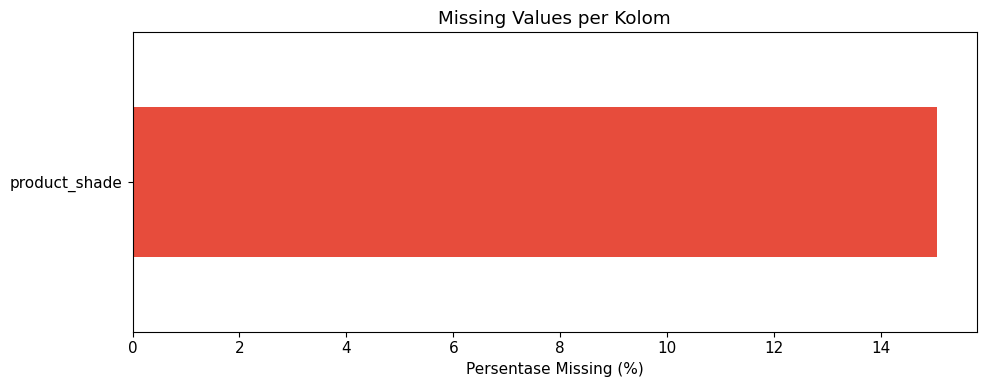

In [8]:
# ============================================================
# CEK MISSING VALUES PER KOLOM
# ============================================================
print("=" * 60)
print("MISSING VALUES PER KOLOM")
print("=" * 60)

missing_df = pd.DataFrame({
    'Jumlah Missing': df_raw.isnull().sum(),
    'Persentase (%)': (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
})
print(missing_df)

# Visualisasi missing values
fig, ax = plt.subplots(figsize=(10, 4))
missing_pct = (df_raw.isnull().sum() / len(df_raw) * 100)
missing_pct[missing_pct > 0].plot(kind='barh', ax=ax, color='#e74c3c')
ax.set_xlabel('Persentase Missing (%)')
ax.set_title('Missing Values per Kolom')
plt.tight_layout()
plt.savefig('plot_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ============================================================
# CEK KOLOM WAJIB: review_text tidak boleh null
# ============================================================
df = df_raw.copy()

# Hapus baris dengan review_text kosong/null
before = len(df)
df = df.dropna(subset=['review_text'])
df = df[df['review_text'].str.strip() != '']
after = len(df)

print(f"🗑️  Baris dihapus (review_text null/kosong) : {before - after:,}")
print(f"✅ Sisa data                                : {after:,}")

🗑️  Baris dihapus (review_text null/kosong) : 0
✅ Sisa data                                : 4,200


In [10]:
# ============================================================
# HAPUS KOLOM product_url (tidak relevan untuk ABSA)
# Tetap simpan sebagai backup sebelum dihapus
# ============================================================
if 'product_url' in df.columns:
    df_backup_url = df[['product_url']].copy()  # simpan backup
    df = df.drop(columns=['product_url'])
    print("✅ Kolom 'product_url' dihapus (tidak relevan untuk ABSA)")
    print("   → Backup URL tersimpan di variabel 'df_backup_url'")

print(f"\n📋 Kolom tersisa: {list(df.columns)}")

✅ Kolom 'product_url' dihapus (tidak relevan untuk ABSA)
   → Backup URL tersimpan di variabel 'df_backup_url'

📋 Kolom tersisa: ['product_brand', 'product_name', 'product_shade', 'product_price', 'review_date', 'review_text']


---

## 4. Standarisasi Format Kolom


In [11]:
# ============================================================
# 4A. STANDARISASI product_price
# Referensi: format harga tidak konsisten dari hasil scraping
# ============================================================

def clean_price(price_str):
    """
    Standarisasi format harga ke integer.
    Contoh: 'Rp35.000' / 'IDR 35,000' / '35000' → 35000
    """
    if pd.isna(price_str):
        return np.nan
    price_str = str(price_str)
    # Hapus semua karakter non-numerik
    price_clean = re.sub(r'[^\d]', '', price_str)
    if price_clean == '':
        return np.nan
    return int(price_clean)

if 'product_price' in df.columns:
    df['product_price_clean'] = df['product_price'].apply(clean_price)
    print("✅ Standarisasi product_price selesai")
    print(f"   Contoh sebelum: {df['product_price'].head(3).tolist()}")
    print(f"   Contoh sesudah: {df['product_price_clean'].head(3).tolist()}")
    print(f"\n   Statistik harga:")
    print(df['product_price_clean'].describe())

✅ Standarisasi product_price selesai
   Contoh sebelum: ['Rp.27.500', 'Rp.27.500', 'Rp.27.500']
   Contoh sesudah: [27500, 27500, 27500]

   Statistik harga:
count      4200.000000
mean      37835.857143
std       35866.235504
min           0.000000
25%       19000.000000
50%       25000.000000
75%       34000.000000
max      139000.000000
Name: product_price_clean, dtype: float64


In [ ]:
# ============================================================
# 4B. STANDARISASI product_brand & product_name & product_shade
# Normalisasi kapitalisasi
# ============================================================

for col in ['product_brand', 'product_name', 'product_shade']:
    if col in df.columns:
        # Title case untuk konsistensi
        df[col] = df[col].str.strip().str.title()
        # Isi missing shade dengan 'No Shade'
        if col == 'product_shade':
            df[col] = df[col].fillna('No Shade')
        print(f"✅ Standarisasi '{col}' selesai | Unik: {df[col].nunique()}")

print(f"\n🏷️  Top 10 Brand:")
print(df['product_brand'].value_counts().head(10).to_string() if 'product_brand' in df.columns else 'N/A')

✅ Standarisasi 'product_brand' selesai | Unik: 10
✅ Standarisasi 'product_name' selesai | Unik: 11
✅ Standarisasi 'product_shade' selesai | Unik: 11

🏷️  Top 10 Brand:
product_brand
Maybelline    1031
Implora        682
Himalaya       632
Nivea          560
Tony Moly      410
Blp Beauty     305
Mahana         258
Wardah         210
Mirelle         57
Omg             55


✅ Parsing review_date selesai
   Rentang tanggal : 2015-08-22 s/d 2026-02-25
   Tanggal invalid : 0


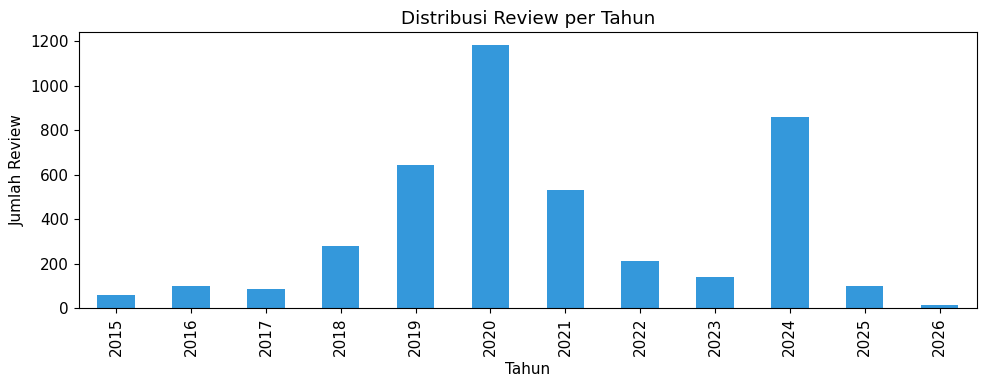

💾 Plot disimpan: plot_review_per_tahun.png


In [13]:
# ============================================================
# 4C. STANDARISASI review_date
# Parse ke format datetime standar
# ============================================================

if 'review_date' in df.columns:
    df['review_date'] = pd.to_datetime(df['review_date'], errors='coerce')
    
    # Deteksi outlier tanggal (terlalu lama atau masa depan)
    date_min = df['review_date'].min()
    date_max = df['review_date'].max()
    invalid_dates = df['review_date'].isna().sum()
    
    print(f"✅ Parsing review_date selesai")
    print(f"   Rentang tanggal : {date_min.date()} s/d {date_max.date()}")
    print(f"   Tanggal invalid : {invalid_dates}")
    
    # Visualisasi distribusi review per tahun
    df['review_year'] = df['review_date'].dt.year
    fig, ax = plt.subplots(figsize=(10, 4))
    df['review_year'].value_counts().sort_index().plot(kind='bar', ax=ax, color='#3498db')
    ax.set_xlabel('Tahun')
    ax.set_ylabel('Jumlah Review')
    ax.set_title('Distribusi Review per Tahun')
    plt.tight_layout()
    plt.savefig('plot_review_per_tahun.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("💾 Plot disimpan: plot_review_per_tahun.png")

---

## 5. Filtering Data Tidak Relevan


In [ ]:
# ============================================================
# 5A. FILTER REVIEW TERLALU PENDEK (< 3 kata)
# Review sangat pendek tidak informatif untuk identifikasi aspek
# Referensi: Schouten & Frasincar (2016) IEEE TKDE
# ============================================================

MIN_WORD_COUNT = 3

df['word_count'] = df['review_text'].apply(lambda x: len(str(x).split()))

short_reviews = df[df['word_count'] < MIN_WORD_COUNT]
print(f"📊 Review dengan < {MIN_WORD_COUNT} kata: {len(short_reviews):,}")
if len(short_reviews) > 0:
    print("\n📋 Contoh review pendek:")
    print(short_reviews['review_text'].head(10).tolist())

before = len(df)
df = df[df['word_count'] >= MIN_WORD_COUNT]
print(f"\n🗑️  Baris dihapus : {before - len(df):,}")
print(f"✅ Sisa data     : {len(df):,}")

📊 Review dengan < 3 kata: 20

📋 Contoh review pendek:
['Yyyjjvgggghudgggggfyyduutiyggg8ydydydyfyfydufufufufdyfyfyfyfufufufuffuyfydyfufufydufydydydydydystsdyydydjgkvhhcgdydydd5dtdyryfyfydufut7yugufufyfgfiguutufufyfugugugigugufydyfuigufydyfuhuigihigfiyfyff67fft', 'Imploraaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaasaaaaaaaaaaaaaaaaaaaaaaaaasasssaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa', 'Bbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbhbbbbbbbbbbbbaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaannnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnggggggggggggggggggggggggggggggggggggggggggggggeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeetttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttt', 'Bagus bangetttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttt

---

## 7. Cleaning `review_text`

> Tahap ini membersihkan teks untuk mempermudah anotasi di Label Studio


In [15]:
# ============================================================
# LOAD KAMUS SLANG DARI GITHUB
#
# Sumber: nasalsabila/kamus-alay — colloquial-indonesian-lexicon.csv
# Publikasi: Salsabila et al. (2018) IALP/IEEE
# https://github.com/nasalsabila/kamus-alay
# ============================================================

URL_KAMUS_ALAY = 'https://raw.githubusercontent.com/nasalsabila/kamus-alay/master/colloquial-indonesian-lexicon.csv'

def load_kamus_from_github(url, col_slang, col_formal, label=''):
    """
    Load kamus slang dari GitHub raw URL.
    Mengembalikan dict {slang: formal}.
    """
    try:
        df_kamus = pd.read_csv(url, header=0, encoding='utf-8',
                               on_bad_lines='skip')
        # Pastikan kolom ada
        if col_slang not in df_kamus.columns or col_formal not in df_kamus.columns:
            df_kamus = pd.read_csv(url, header=None, encoding='utf-8',
                                   on_bad_lines='skip')
            df_kamus.columns = [col_slang, col_formal]
        df_kamus = df_kamus[[col_slang, col_formal]].dropna()
        df_kamus[col_slang]  = df_kamus[col_slang].str.lower().str.strip()
        df_kamus[col_formal] = df_kamus[col_formal].str.lower().str.strip()
        kamus = dict(zip(df_kamus[col_slang], df_kamus[col_formal]))
        print(f"  ✅ {label}: {len(kamus):,} entri berhasil dimuat")
        return kamus
    except Exception as e:
        print(f"  ⚠️  {label} gagal dimuat: {e}")
        return {}

print("🌐 Mengunduh kamus slang dari GitHub...")

# Load kamus dari nasalsabila/kamus-alay
SLANG_DICT = load_kamus_from_github(
    URL_KAMUS_ALAY,
    col_slang='slang', col_formal='formal',
    label='nasalsabila/kamus-alay'
)

print(f"\n📚 Total SLANG_DICT: {len(SLANG_DICT):,} entri")
print("\n🔍 Contoh 10 entri pertama:")
for k, v in list(SLANG_DICT.items())[:10]:
    print(f"   '{k}' → '{v}'")


🌐 Mengunduh kamus slang dari GitHub...
  ✅ nasalsabila/kamus-alay: 4,330 entri berhasil dimuat

📚 Total SLANG_DICT: 4,330 entri

🔍 Contoh 10 entri pertama:
   'woww' → 'wow'
   'aminn' → 'amin'
   'met' → 'selamat'
   'netaas' → 'menetas'
   'keberpa' → 'keberapa'
   'eeeehhhh' → 'eh'
   'kata2nyaaa' → 'kata-katanya'
   'hallo' → 'halo'
   'kaka' → 'kakak'
   'ka' → 'kak'


In [16]:
# ============================================================
# FUNGSI CLEANING UTAMA
# ============================================================

def normalize_unicode(text):
    """Normalisasi encoding Unicode."""
    return unicodedata.normalize('NFKC', str(text))

def remove_url(text):
    """Hapus URL dan link."""
    return re.sub(r'http\S+|www\.\S+', '', text)

def remove_html_tags(text):
    """Hapus HTML tags dari hasil scraping."""
    return re.sub(r'<[^>]+>', ' ', text)

def normalize_newlines(text):
    """Ganti newline dan tab dengan spasi."""
    return re.sub(r'[\n\r\t]+', ' ', text)



def normalize_emoji(text):
    """
    Hapus emoji berlebihan (simpan konteks sentimen jika perlu).
    Referensi: Zhang et al. (2022) - emoji dapat membawa sinyal sentimen
    """
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport
        u"\U0001F1E0-\U0001F1FF"  # flags
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
    "]+", flags=re.UNICODE)
    return emoji_pattern.sub(' ', text)

def fix_mojibake(text):
    """
    Perbaiki karakter mojibake hasil encoding error saat scraping.
    Menggunakan library ftfy (fixes text for you) yang dirancang
    khusus untuk masalah ini.
    Referensi: Speer (2019) ftfy — https://ftfy.readthedocs.io
    """
    return ftfy.fix_text(str(text))

def normalize_slang(text, slang_dict):
    """
    Normalisasi kata slang dan singkatan.
    Referensi: Salsabila et al. (2018)
    """
    words = text.split()
    return ' '.join([slang_dict.get(w.lower(), w) for w in words])

def normalize_repeated_chars(text):
    """Normalisasi karakter berulang: 'bagusssss' → 'bagus'."""
    return re.sub(r'(.)\1{2,}', r'\1\1', text)  # max 2 karakter sama

def normalize_whitespace(text):
    """Normalisasi spasi berlebih."""
    return re.sub(r'\s+', ' ', text).strip()

def remove_mojibake(text):
    """
    Hapus karakter mojibake (emoji rusak/encoding error).
    Hanya pertahankan karakter ASCII, huruf Indonesia, dan tanda baca umum.
    """
    # Hapus karakter non-ASCII yang bukan huruf/angka/tanda baca standar
    text = re.sub(r'[^\x00-\x7F\u00C0-\u024F]', ' ', text)
    # Hapus sisa karakter kontrol dan simbol aneh
    text = re.sub(r'[ðâïï¿½¾¼¡¿]+', ' ', text)
    return text


def clean_review_text(text, slang_dict=SLANG_DICT):
    """
    Pipeline cleaning utama untuk review_text.
    """
    text = fix_mojibake(text)
    text = normalize_unicode(text)        
    text = remove_html_tags(text)            
    text = remove_url(text)                 
    text = normalize_newlines(text)        
    text = normalize_emoji(text)             
    text = normalize_repeated_chars(text)    
    text = normalize_slang(text, slang_dict) 
    text = normalize_whitespace(text)        
    return text


print("✅ Fungsi cleaning berhasil didefinisikan")

# Test fungsi
test_texts = [
    "lipstik ini bagussss bgt!! warnanya pigmented bgt gak perlu reapply\n",
    "ga cocok sm kulit saya 😭😭😭 mahal tp kualitasnya mengecewakan",
    "worth it banget!! udh 3x repurchase krn tahan lamanya"
]
print("\n🧪 Test cleaning:")
for t in test_texts:
    print(f"   Sebelum: {t[:60]}")
    print(f"   Sesudah: {clean_review_text(t)[:60]}")
    print()

✅ Fungsi cleaning berhasil didefinisikan

🧪 Test cleaning:
   Sebelum: lipstik ini bagussss bgt!! warnanya pigmented bgt gak perlu 
   Sesudah: lipstik ini bagus bgt!! warnanya pigmented banget enggak per

   Sebelum: ga cocok sm kulit saya 😭😭😭 mahal tp kualitasnya mengecewakan
   Sesudah: enggak cocok sama kulit saya mahal tapi kualitasnya mengecew

   Sebelum: worth it banget!! udh 3x repurchase krn tahan lamanya
   Sesudah: worth itu banget!! sudah 3x repurchase karena tahan lamanya



In [17]:
# ============================================================
# TERAPKAN CLEANING KE SELURUH DATASET
# ============================================================

print("🔄 Menerapkan cleaning ke seluruh review_text...")

# Simpan teks asli sebagai backup
df['review_text_original'] = df['review_text'].copy()

# Terapkan cleaning
df['review_text_clean'] = df['review_text'].apply(clean_review_text)

print("✅ Cleaning selesai!")
print(f"\n📋 Perbandingan sebelum & sesudah:")
comparison = df[['review_text_original', 'review_text_clean']].head(3)
for i, row in comparison.iterrows():
    print(f"\n[{i}] Sebelum: {row['review_text_original'][:100]}")
    print(f"[{i}] Sesudah: {row['review_text_clean'][:100]}")

🔄 Menerapkan cleaning ke seluruh review_text...
✅ Cleaning selesai!

📋 Perbandingan sebelum & sesudah:

[0] Sebelum: Omg tuh selain harganya yang affordable, ternyata kualitasnya oke juga. Menurutku dia teksturnya cuk
[0] Sesudah: Omg tuh selain harganya yang affordable, ternyata kualitasnya oke juga. Menurutku dia teksturnya cuk

[1] Sebelum: Produk favorite aku yang udah gatau berapa lipcream reorder ðâ¦ pokoknya ini bangus banget dan a
[1] Sesudah: Produk favorite aku yang sudah enggak tau berapa lipcream reorder .. pokoknya ini bangus banget dan 

[2] Sebelum: aku terinfluence dari teman aku, terus aku coba pakai dan rupanya ga terlalu kering dan awet banget 
[2] Sesudah: aku terinfluence dari teman aku, terus aku coba pakai dan rupanya enggak terlalu kering dan awet ban


In [ ]:
# ============================================================
# FILTER ULANG SETELAH CLEANING
# Review mungkin menjadi terlalu pendek setelah cleaning
# ============================================================

df['word_count_clean'] = df['review_text_clean'].apply(lambda x: len(str(x).split()))

before = len(df)
df = df[df['word_count_clean'] >= MIN_WORD_COUNT]
print(f"🗑️  Baris dihapus setelah cleaning (< {MIN_WORD_COUNT} kata): {before - len(df):,}")
print(f"✅ Total data bersih: {len(df):,}")

🗑️  Baris dihapus setelah cleaning (< 3 kata): 0
✅ Total data bersih: 4,180


---

## 8. Eksplorasi Data (EDA)


In [ ]:
# ============================================================
# RINGKASAN PIPELINE
# ============================================================

print("=" * 60)
print("RINGKASAN PIPELINE PREPROCESSING")
print("=" * 60)
print(f"Data awal           : {df_raw.shape[0]:,} baris")
print(f"Data akhir (bersih) : {len(df):,} baris")
print(f"Total terhapus      : {df_raw.shape[0] - len(df):,} baris ({(df_raw.shape[0] - len(df)) / df_raw.shape[0] * 100:.1f}%)")

RINGKASAN PIPELINE PREPROCESSING
Data awal           : 4,200 baris
Data akhir (bersih) : 4,180 baris
Total terhapus      : 20 baris (0.5%)


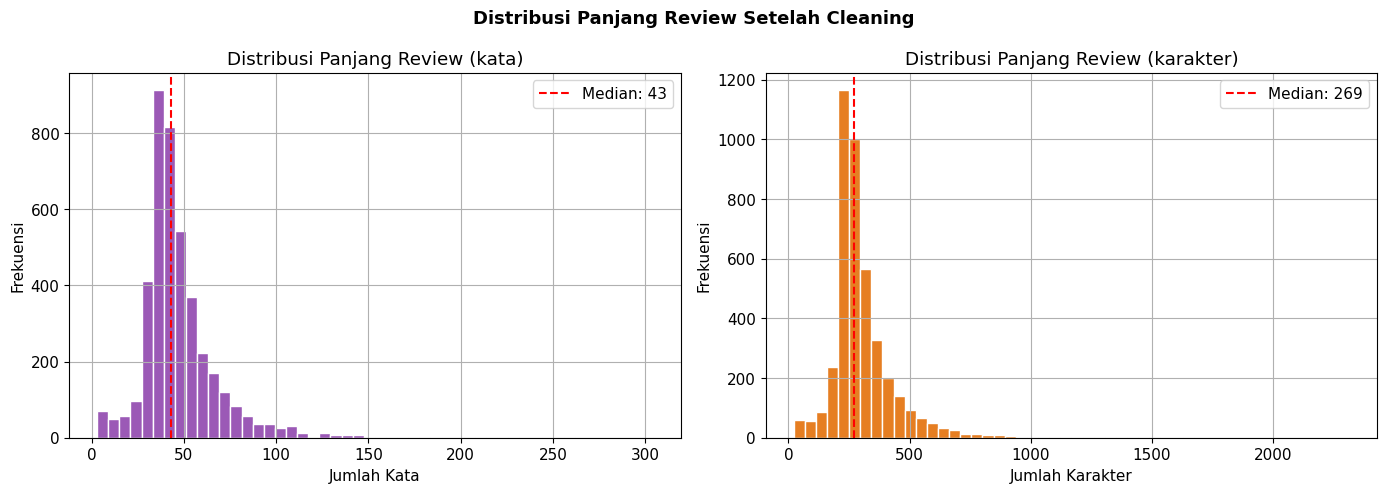

💾 Plot disimpan: plot_panjang_review.png

📊 Statistik panjang review:
       word_count_clean  char_count
count            4180.0      4180.0
mean               47.8       302.7
std                22.4       140.3
min                 3.0        21.0
25%                36.0       229.0
50%                43.0       269.0
75%                54.0       340.0
max               304.0      2316.0


In [20]:
# ============================================================
# DISTRIBUSI PANJANG REVIEW
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Word count distribution
df['word_count_clean'].hist(bins=50, ax=axes[0], color='#9b59b6', edgecolor='white')
axes[0].set_xlabel('Jumlah Kata')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Distribusi Panjang Review (kata)')
axes[0].axvline(df['word_count_clean'].median(), color='red', linestyle='--', label=f'Median: {df["word_count_clean"].median():.0f}')
axes[0].legend()

# Character count
df['char_count'] = df['review_text_clean'].apply(len)
df['char_count'].hist(bins=50, ax=axes[1], color='#e67e22', edgecolor='white')
axes[1].set_xlabel('Jumlah Karakter')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi Panjang Review (karakter)')
axes[1].axvline(df['char_count'].median(), color='red', linestyle='--', label=f'Median: {df["char_count"].median():.0f}')
axes[1].legend()

plt.suptitle('Distribusi Panjang Review Setelah Cleaning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_panjang_review.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Plot disimpan: plot_panjang_review.png")

print(f"\n📊 Statistik panjang review:")
print(df[['word_count_clean', 'char_count']].describe().round(1).to_string())

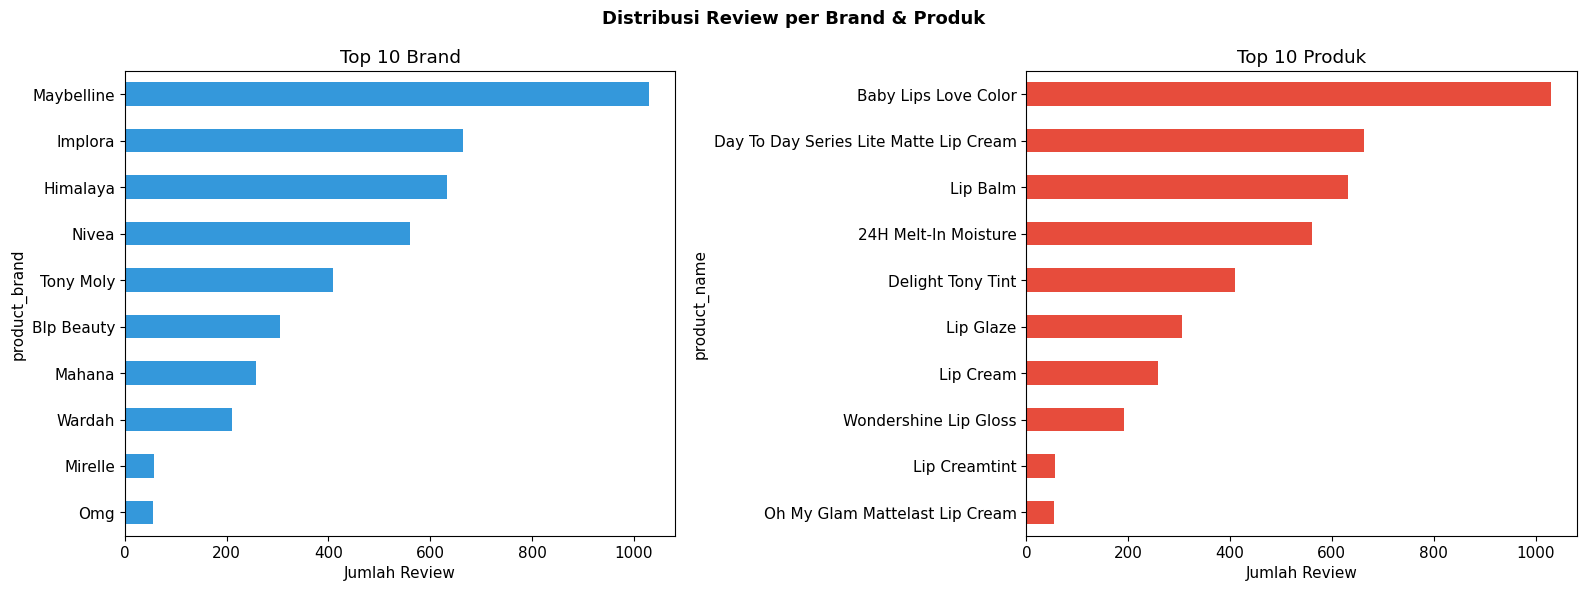

💾 Plot disimpan: plot_distribusi_brand_produk.png


In [21]:
# ============================================================
# TOP BRAND & PRODUK
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top Brand
if 'product_brand' in df.columns:
    top_brands = df['product_brand'].value_counts().head(10)
    top_brands.plot(kind='barh', ax=axes[0], color='#3498db')
    axes[0].set_xlabel('Jumlah Review')
    axes[0].set_title('Top 10 Brand')
    axes[0].invert_yaxis()

# Top Produk
if 'product_name' in df.columns:
    top_products = df['product_name'].value_counts().head(10)
    top_products.plot(kind='barh', ax=axes[1], color='#e74c3c')
    axes[1].set_xlabel('Jumlah Review')
    axes[1].set_title('Top 10 Produk')
    axes[1].invert_yaxis()

plt.suptitle('Distribusi Review per Brand & Produk', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_distribusi_brand_produk.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Plot disimpan: plot_distribusi_brand_produk.png")

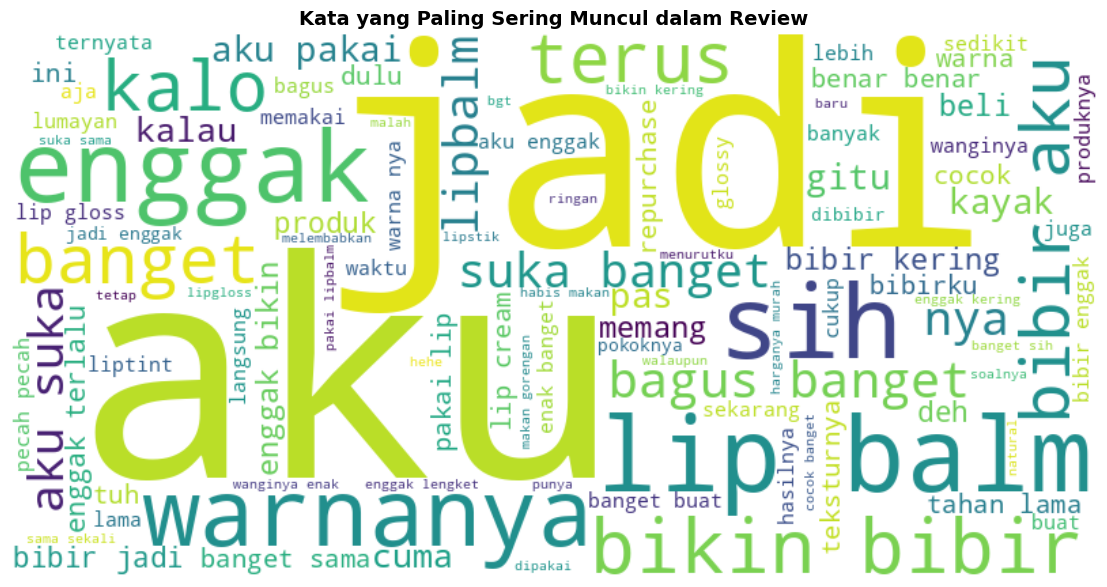

💾 Plot disimpan: plot_wordcloud.png


In [22]:
# ============================================================
# WORDCLOUD REVIEW (kata yang sering muncul)
# ============================================================

try:
    from wordcloud import WordCloud
    
    factory = StopWordRemoverFactory()
    stopwords_id = set(factory.get_stop_words())
    
    # Gabungkan semua review
    all_text = ' '.join(df['review_text_clean'].tolist())
    
    # Hapus stopwords untuk wordcloud saja
    words = [w for w in all_text.lower().split() if w not in stopwords_id and len(w) > 2]
    text_for_cloud = ' '.join(words)
    
    wordcloud = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap='viridis',
        max_words=100,
        min_font_size=10
    ).generate(text_for_cloud)
    
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    ax.set_title('Kata yang Paling Sering Muncul dalam Review', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plot_wordcloud.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("💾 Plot disimpan: plot_wordcloud.png")

except ImportError:
    print("⚠️  WordCloud tidak tersedia. Install dengan: pip install wordcloud")

---

## 9. Ekspor Dataset untuk Label Studio


In [23]:
# ============================================================
# 9A. EKSPOR FORMAT CSV UNTUK LABEL STUDIO
# ============================================================

df = df.reset_index(drop=True)
df['review_id'] = ['review_' + str(i+1).zfill(5) for i in range(len(df))]

# Hanya 6 kolom yang diperlukan untuk Label Studio
cols_for_labeling = [
    'review_id',
    'review_text_clean',
    'product_brand',
    'product_name',
    'product_shade',
    'product_price_clean'
]

# Filter kolom yang benar-benar ada di df (antisipasi jika ada yang missing)
cols_for_labeling = [c for c in cols_for_labeling if c in df.columns]

df_for_label_studio = df[cols_for_labeling].copy()

# Rename agar nama kolom bersih dan cocok dengan $variable di XML Label Studio
df_for_label_studio = df_for_label_studio.rename(columns={
    'review_text_clean'  : 'text',
    'product_price_clean': 'product_price'
})

# Simpan CSV
output_csv = '/content/drive/MyDrive/TA/data/dataset_for_label_studio.csv'
df_for_label_studio.to_csv(output_csv, index=False, encoding='utf-8-sig')

print(f"✅ Dataset untuk Label Studio tersimpan: {output_csv}")
print(f"   Jumlah data : {len(df_for_label_studio):,}")
print(f"   Kolom       : {list(df_for_label_studio.columns)}")
print("\n📋 Preview:")
display(df_for_label_studio.head(3))

✅ Dataset untuk Label Studio tersimpan: /content/drive/MyDrive/TA/data/dataset_for_label_studio.csv
   Jumlah data : 4,180
   Kolom       : ['review_id', 'text', 'product_brand', 'product_name', 'product_shade', 'product_price']

📋 Preview:


,review_id,text,product_brand,product_name,product_shade,product_price
0,review_00001,"Omg tuh selain harganya yang affordable, ternyata kualitasnya oke juga. Menurutku dia teksturnya cukup ringan di bibir, buat menutupi bibir yang h...",Omg,Oh My Glam Mattelast Lip Cream,24 Berry,27500
1,review_00002,Produk favorite aku yang sudah enggak tau berapa lipcream reorder .. pokoknya ini bangus banget dan aku biasanya pakai shade ini buat ombre .. apa...,Omg,Oh My Glam Mattelast Lip Cream,24 Berry,27500
2,review_00003,"aku terinfluence dari teman aku, terus aku coba pakai dan rupanya enggak terlalu kering dan awet banget dipakai seharian, sudah dipakai makan gore...",Omg,Oh My Glam Mattelast Lip Cream,24 Berry,27500


In [24]:
# ============================================================
# 9B. EKSPOR FORMAT JSON UNTUK LABEL STUDIO
# Format JSON lebih fleksibel untuk konfigurasi Label Studio
# ============================================================

label_studio_json = []
for _, row in df_for_label_studio.iterrows():
    entry = {
        'id': row['review_id'],
        'data': {}
    }
    for col in df_for_label_studio.columns:
        if col != 'review_id':
            val = row[col]
            entry['data'][col] = val if pd.notna(val) else ''
    label_studio_json.append(entry)

output_json = '/content/drive/MyDrive/TA/data/dataset_for_label_studio.json'
with open(output_json, 'w', encoding='utf-8') as f:
    json.dump(label_studio_json, f, ensure_ascii=False, indent=2)

print(f"✅ Dataset JSON tersimpan: {output_json}")
print(f"   Jumlah entri: {len(label_studio_json):,}")
print("\n📋 Contoh struktur JSON:")
print(json.dumps(label_studio_json[0], ensure_ascii=False, indent=2))

✅ Dataset JSON tersimpan: /content/drive/MyDrive/TA/data/dataset_for_label_studio.json
   Jumlah entri: 4,180

📋 Contoh struktur JSON:
{
  "id": "review_00001",
  "data": {
    "text": "Omg tuh selain harganya yang affordable, ternyata kualitasnya oke juga. Menurutku dia teksturnya cukup ringan di bibir, buat menutupi bibir yang hitam juga bisa dan pilihan shadenya beragam. dipakai buat ombre lips juga cocok banget",
    "product_brand": "Omg",
    "product_name": "Oh My Glam Mattelast Lip Cream",
    "product_shade": "24 Berry",
    "product_price": 27500
  }
}


In [25]:
import os


# ============================================================
# 9C. SIMPAN DATASET LENGKAP SEBAGAI BACKUP
# Termasuk teks asli, teks bersih, dan metadata lainnya
# ============================================================

output_backup = '/content/drive/MyDrive/TA/data/dataset_processed.csv'
os.makedirs(os.path.dirname(output_backup), exist_ok=True)
df.to_csv(output_backup, index=False, encoding='utf-8-sig')

print(f"✅ Dataset backup tersimpan: {output_backup}")
print(f"   Jumlah kolom: {df.shape[1]}")
print(f"   Kolom       : {list(df.columns)}")

✅ Dataset backup tersimpan: /content/drive/MyDrive/TA/data/dataset_processed.csv
   Jumlah kolom: 14
   Kolom       : ['product_brand', 'product_name', 'product_shade', 'product_price', 'review_date', 'review_text', 'product_price_clean', 'review_year', 'word_count', 'review_text_original', 'review_text_clean', 'word_count_clean', 'char_count', 'review_id']


In [26]:
# ============================================================
# RINGKASAN AKHIR
# ============================================================

print("=" * 65)
print("  RINGKASAN AKHIR PRE-ANNOTATION PREPARATION")
print("=" * 65)
print(f"  📥 Data awal                  : {df_raw.shape[0]:>6,} baris")
print(f"  🗑️  Null/kosong dihapus         : {df_raw.shape[0] - df_raw.dropna(subset=['review_text']).shape[0]:>6,} baris")
print(f"  🗑️  Review terlalu pendek dihapus: lihat log di atas")
print(f"  ✅ Data bersih siap anotasi    : {len(df):>6,} baris")

  RINGKASAN AKHIR PRE-ANNOTATION PREPARATION
  📥 Data awal                  :  4,200 baris
  🗑️  Null/kosong dihapus         :      0 baris
  🗑️  Review terlalu pendek dihapus: lihat log di atas
  ✅ Data bersih siap anotasi    :  4,180 baris


---

## 10. Ekspor IPYNB ke drive


In [ ]:
from google.colab import files
import shutil

# Step 1: Upload file .ipynb dari laptop ke Colab VM
print("📂 Pilih file .ipynb dari laptop kamu:")
uploaded = files.upload()  # Akan muncul tombol upload

# Step 2: Copy file yang diupload ke Google Drive
for filename in uploaded:
    dest = f'/content/drive/MyDrive/TA/data/{filename}'
    with open(dest, 'wb') as f:
        f.write(uploaded[filename])
    print(f"✅ '{filename}' tersimpan ke Google Drive: {dest}")


📂 Pilih file .ipynb dari laptop kamu:
